# Image Blending, Alpha Compositing & Photographic Blend Modes

### Mathematical Foundations of Image Blending:

#### 1. Normalized Image Representation:
Let the foreground image $F(x, y)$ and background image $B(x, y)$ have color channels normalized to $[0, 1]$:
$$F = \frac{I_{\text{foreground}}}{255.0}, \quad B = \frac{I_{\text{background}}}{255.0}, \quad F, B \in [0, 1]$$

#### 2. Linear Alpha Blending (Simple Cross-Dissolve):
For a constant blending factor $\alpha \in [0, 1]$:
$$C_{\text{linear}} = (1 - \alpha) \cdot B + \alpha \cdot F = B + \alpha (F - B)$$
In OpenCV, this is computed via `cv2.addWeighted(F, alpha, B, 1 - alpha, 0.0)`.

#### 3. Porter-Duff "Over" Alpha Compositing (General Alpha Handling):
When foreground has opacity $\alpha_F \in [0, 1]$ and background has opacity $\alpha_B \in [0, 1]$:
- **Composite Alpha Channel ($\alpha_C$):**
  $$\alpha_C = \alpha_F + \alpha_B (1 - \alpha_F)$$
- **Composite Color ($C$):**
  $$C = \frac{F \cdot \alpha_F + B \cdot \alpha_B (1 - \alpha_F)}{\alpha_C} \quad (\text{for } \alpha_C > 0)$$
*(Note: If $\alpha_B = 1.0$, then $\alpha_C = 1.0$ and $C = \alpha_F F + (1 - \alpha_F) B$, which reduces to linear alpha blending. If $\alpha_B < 1.0$, alpha compositing correctly accounts for background transparency).*

#### 4. Non-Linear Photographic Blend Modes (Implemented in $[0, 1]$):
- **Multiply Blend Mode (Darkening / Subtractive Color):**
  $$C_{\text{multiply}} = F \times B$$
  *(Neutral element is White $1.0$; Absorbing element is Black $0.0$).*
- **Screen Blend Mode (Brightening / Additive Light):**
  $$C_{\text{screen}} = 1 - (1 - F)(1 - B) = F + B - F \times B$$
  *(Neutral element is Black $0.0$; Saturated element is White $1.0$).*
- **Overlay Blend Mode (Contrast & Texture Transfer - Conditioned on Background $B$):**
  $$C_{\text{overlay}} = \begin{cases} 2 \cdot F \cdot B & \text{if } B \le 0.5 \\ 1 - 2(1 - F)(1 - B) & \text{if } B > 0.5 \end{cases}$$
- **Hard Light Blend Mode (Direct Lighting - Conditioned on Foreground $F$):**
  $$C_{\text{hard\_light}} = \begin{cases} 2 \cdot F \cdot B & \text{if } F \le 0.5 \\ 1 - 2(1 - F)(1 - B) & \text{if } F > 0.5 \end{cases}$$
  *(Mathematically equivalent to $\text{Overlay}(B, F)$ with swapped layer order).*
- **Soft Light Blend Mode (Subtle Diffuse Lighting - Pegtop Model):**
  $$C_{\text{soft\_light}} = (1 - 2F) B^2 + 2 F B = B + (2F - 1)(B - B^2)$$

---
This notebook:
1. Loads two test color images (foreground and background) and resizes them to matching spatial dimensions.
2. Performs Linear Alpha Blending across varying $\alpha$ values ($\alpha = 0.0, 0.3, 0.5, 0.7, 1.0$).
3. Implements Porter-Duff "Over" Alpha Compositing with full spatial alpha map handling and compares against simple alpha blending.
4. Implements Multiply, Screen, Overlay, Hard Light, and Soft Light blend modes from scratch using vectorized NumPy.
5. Visualizes composite images, luminance shifts, and comparative histograms across all blend modes.
6. Discusses real-world applications in VFX, game engine rendering, and digital photo retouching.


In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Configure matplotlib rendering settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8


## (i) Load Foreground & Background Images and Match Dimensions

             INPUT IMAGE PROPERTIES (RESIZED & MATCHED)
Foreground Dimensions : 640 x 612 x 3 (RGB)
Background Dimensions : 640 x 612 x 3 (RGB)
Normalized Dynamic Range: FG=[0.00, 1.00], BG=[0.00, 0.97]


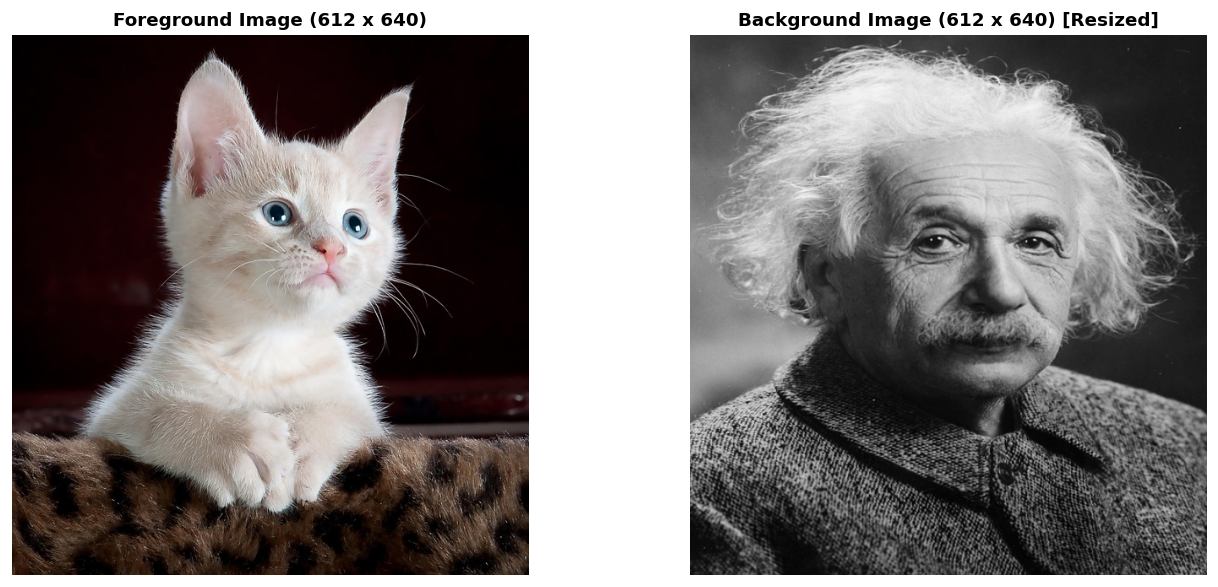

In [2]:
def load_and_match_images(path_fg: str = "images/image1.jpg", path_bg: str = "images/image2.jpg") -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Load two color images, convert to RGB, and resize background to match foreground dimensions.
    Returns:
        img_fg_rgb, img_bg_rgb: uint8 RGB images [0, 255]
        fg_norm, bg_norm: float64 normalized images [0.0, 1.0]
    """
    if not os.path.exists(path_fg) or not os.path.exists(path_bg):
        raise FileNotFoundError(f"One or both images missing: {path_fg}, {path_bg}")
        
    bgr_fg = cv2.imread(path_fg, cv2.IMREAD_COLOR)
    bgr_bg = cv2.imread(path_bg, cv2.IMREAD_COLOR)
    
    rgb_fg = cv2.cvtColor(bgr_fg, cv2.COLOR_BGR2RGB)
    rgb_bg = cv2.cvtColor(bgr_bg, cv2.COLOR_BGR2RGB)
    
    h, w = rgb_fg.shape[:2]
    # Resize background to match foreground dimensions exactly
    rgb_bg_resized = cv2.resize(rgb_bg, (w, h), interpolation=cv2.INTER_AREA)
    
    # Normalize to [0.0, 1.0] float arrays for high-precision blending arithmetic
    fg_norm = rgb_fg.astype(np.float64) / 255.0
    bg_norm = rgb_bg_resized.astype(np.float64) / 255.0
    
    return rgb_fg, rgb_bg_resized, fg_norm, bg_norm


img_fg, img_bg, fg_norm, bg_norm = load_and_match_images("images/image1.jpg", "images/image2.jpg")
h, w, c = img_fg.shape

print("=" * 65)
print("             INPUT IMAGE PROPERTIES (RESIZED & MATCHED)")
print("=" * 65)
print(f"Foreground Dimensions : {h} x {w} x {c} (RGB)")
print(f"Background Dimensions : {img_bg.shape[0]} x {img_bg.shape[1]} x {img_bg.shape[2]} (RGB)")
print(f"Normalized Dynamic Range: FG=[{fg_norm.min():.2f}, {fg_norm.max():.2f}], BG=[{bg_norm.min():.2f}, {bg_norm.max():.2f}]")
print("=" * 65)

# Visual Display of Foreground & Background Images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_fg)
axes[0].set_title(f"Foreground Image ({w} x {h})", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_bg)
axes[1].set_title(f"Background Image ({w} x {h}) [Resized]", fontsize=11, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## (ii) Linear Alpha Blending with Varying Alpha Values (α = 0.0, 0.3, 0.5, 0.7, 1.0)

Alpha = 0.0 | Max difference with cv2.addWeighted: 0 intensity level(s)
Alpha = 0.3 | Max difference with cv2.addWeighted: 1 intensity level(s)
Alpha = 0.5 | Max difference with cv2.addWeighted: 1 intensity level(s)
Alpha = 0.7 | Max difference with cv2.addWeighted: 1 intensity level(s)
Alpha = 1.0 | Max difference with cv2.addWeighted: 0 intensity level(s)


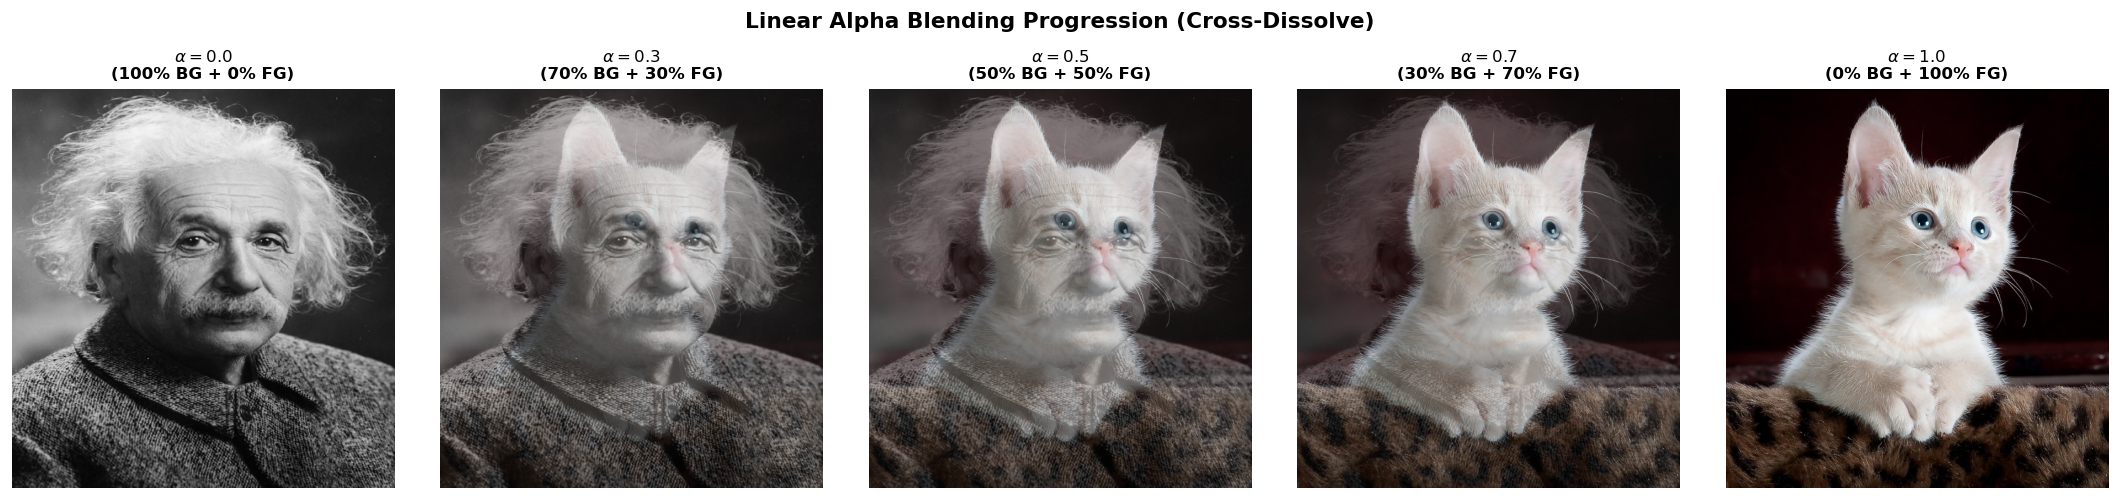

In [3]:
def blend_linear_alpha(fg: np.ndarray, bg: np.ndarray, alpha: float) -> np.ndarray:
    """
    Linear alpha blending: C = (1 - alpha) * BG + alpha * FG
    """
    blended = (1.0 - alpha) * bg + alpha * fg
    return np.clip(np.round(blended * 255.0), 0, 255).astype(np.uint8)


alpha_values = [0.0, 0.3, 0.5, 0.7, 1.0]
linear_blends = [blend_linear_alpha(fg_norm, bg_norm, a) for a in alpha_values]

# Verify with OpenCV cv2.addWeighted
for a, blend_man in zip(alpha_values, linear_blends):
    blend_cv = cv2.addWeighted(img_fg, a, img_bg, 1.0 - a, 0.0)
    max_diff = np.max(np.abs(blend_man.astype(int) - blend_cv.astype(int)))
    print(f"Alpha = {a:.1f} | Max difference with cv2.addWeighted: {max_diff} intensity level(s)")

# Display 5-panel transition grid
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, (a, blended_img) in enumerate(zip(alpha_values, linear_blends)):
    axes[idx].imshow(blended_img)
    axes[idx].set_title(f"$\\alpha = {a:.1f}$\n({int((1-a)*100)}% BG + {int(a*100)}% FG)", fontsize=10, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("Linear Alpha Blending Progression (Cross-Dissolve)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


## (iii) Porter-Duff 'Over' Alpha Compositing with Spatial Alpha Masks

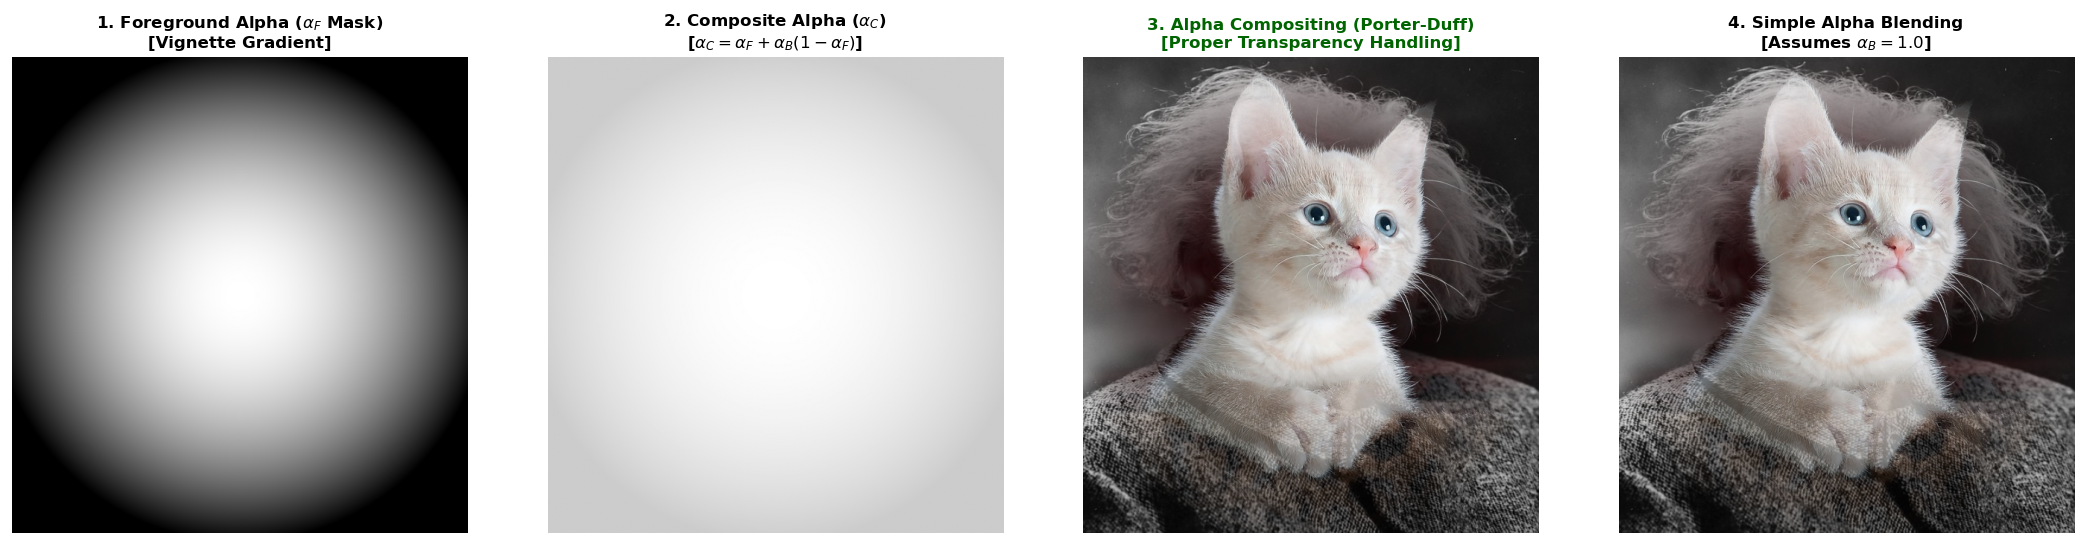

In [4]:
def porter_duff_alpha_compositing(fg: np.ndarray, bg: np.ndarray, alpha_fg: np.ndarray, alpha_bg: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Porter-Duff 'Over' Alpha Compositing:
        alpha_c = alpha_fg + alpha_bg * (1 - alpha_fg)
        C = (FG * alpha_fg + BG * alpha_bg * (1 - alpha_fg)) / alpha_c
    """
    # Composite Alpha Channel
    alpha_c = alpha_fg + alpha_bg * (1.0 - alpha_fg)
    
    # Safe division: where alpha_c > 0
    alpha_c_safe = np.where(alpha_c > 0.0, alpha_c, 1.0)
    color_c = (fg * alpha_fg + bg * alpha_bg * (1.0 - alpha_fg)) / alpha_c_safe
    color_c = np.where(alpha_c > 0.0, color_c, 0.0)
    
    color_uint8 = np.clip(np.round(color_c * 255.0), 0, 255).astype(np.uint8)
    return color_uint8, alpha_c


# Generate spatial alpha masks to illustrate arbitrary compositing
# 1. Foreground Alpha: Circular vignette mask (high opacity in center, transparent at edges)
y_grid, x_grid = np.indices((h, w), dtype=np.float64)
center_y, center_x = h / 2.0, w / 2.0
dist_from_center = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)
max_dist = np.sqrt(center_x**2 + center_y**2)
alpha_fg_mask = np.clip(1.0 - (dist_from_center / (0.75 * max_dist))**2, 0.0, 1.0)[..., np.newaxis]

# 2. Background Alpha: Semi-transparent constant alpha (alpha_B = 0.8)
alpha_bg_mask = np.full((h, w, 1), 0.8, dtype=np.float64)

# Execute Porter-Duff Over Compositing
comp_color, comp_alpha = porter_duff_alpha_compositing(fg_norm, bg_norm, alpha_fg_mask, alpha_bg_mask)

# Compare with simple linear alpha blending under same alpha_fg
simple_blend = np.clip(np.round(((1.0 - alpha_fg_mask) * bg_norm + alpha_fg_mask * fg_norm) * 255.0), 0, 255).astype(np.uint8)

# Visual Display of Alpha Masks and Compositing Result
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(alpha_fg_mask[..., 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title(r"1. Foreground Alpha ($\alpha_F$ Mask)" + "\n[Vignette Gradient]", fontsize=10, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(comp_alpha[..., 0], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(r"2. Composite Alpha ($\alpha_C$)" + "\n[$\\alpha_C = \\alpha_F + \\alpha_B(1-\\alpha_F)$]", fontsize=10, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(comp_color)
axes[2].set_title("3. Alpha Compositing (Porter-Duff)\n[Proper Transparency Handling]", fontsize=10, fontweight="bold", color="darkgreen")
axes[2].axis("off")

axes[3].imshow(simple_blend)
axes[3].set_title(r"4. Simple Alpha Blending" + "\n[Assumes $\\alpha_B = 1.0$]", fontsize=10, fontweight="bold")
axes[3].axis("off")

plt.tight_layout()
plt.show()


## (iv) Non-Linear Photographic Blend Modes (Implemented from Scratch in NumPy)

In [5]:
def blend_multiply(fg: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Multiply Blend Mode: C = F * B
    Multiplies color components, resulting in an overall darker image.
    """
    out = fg * bg
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


def blend_screen(fg: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Screen Blend Mode: C = 1 - (1 - F) * (1 - B)
    Inverts, multiplies, and inverts back, resulting in a brighter image.
    """
    out = 1.0 - (1.0 - fg) * (1.0 - bg)
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


def blend_overlay(fg: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Overlay Blend Mode: Combines Multiply and Screen based on Background (B).
    C = 2*F*B if B <= 0.5 else 1 - 2*(1-F)*(1-B)
    """
    out = np.where(bg <= 0.5, 2.0 * fg * bg, 1.0 - 2.0 * (1.0 - fg) * (1.0 - bg))
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


def blend_hard_light(fg: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Hard Light Blend Mode: Combines Multiply and Screen based on Foreground (F).
    C = 2*F*B if F <= 0.5 else 1 - 2*(1-F)*(1-B)
    """
    out = np.where(fg <= 0.5, 2.0 * fg * bg, 1.0 - 2.0 * (1.0 - fg) * (1.0 - bg))
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


def blend_soft_light(fg: np.ndarray, bg: np.ndarray) -> np.ndarray:
    """
    Soft Light Blend Mode (Pegtop Model): C = (1 - 2F)*B^2 + 2F*B
    Creates subtle, diffused contrast enhancement.
    """
    out = (1.0 - 2.0 * fg) * (bg ** 2) + 2.0 * fg * bg
    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)


# Execute all blend modes
img_multiply   = blend_multiply(fg_norm, bg_norm)
img_screen     = blend_screen(fg_norm, bg_norm)
img_overlay    = blend_overlay(fg_norm, bg_norm)
img_hard_light = blend_hard_light(fg_norm, bg_norm)
img_soft_light = blend_soft_light(fg_norm, bg_norm)

print("Photographic blend modes computed successfully.")


Photographic blend modes computed successfully.


## (v) Display: Visual Comparison of Photographic Blend Modes

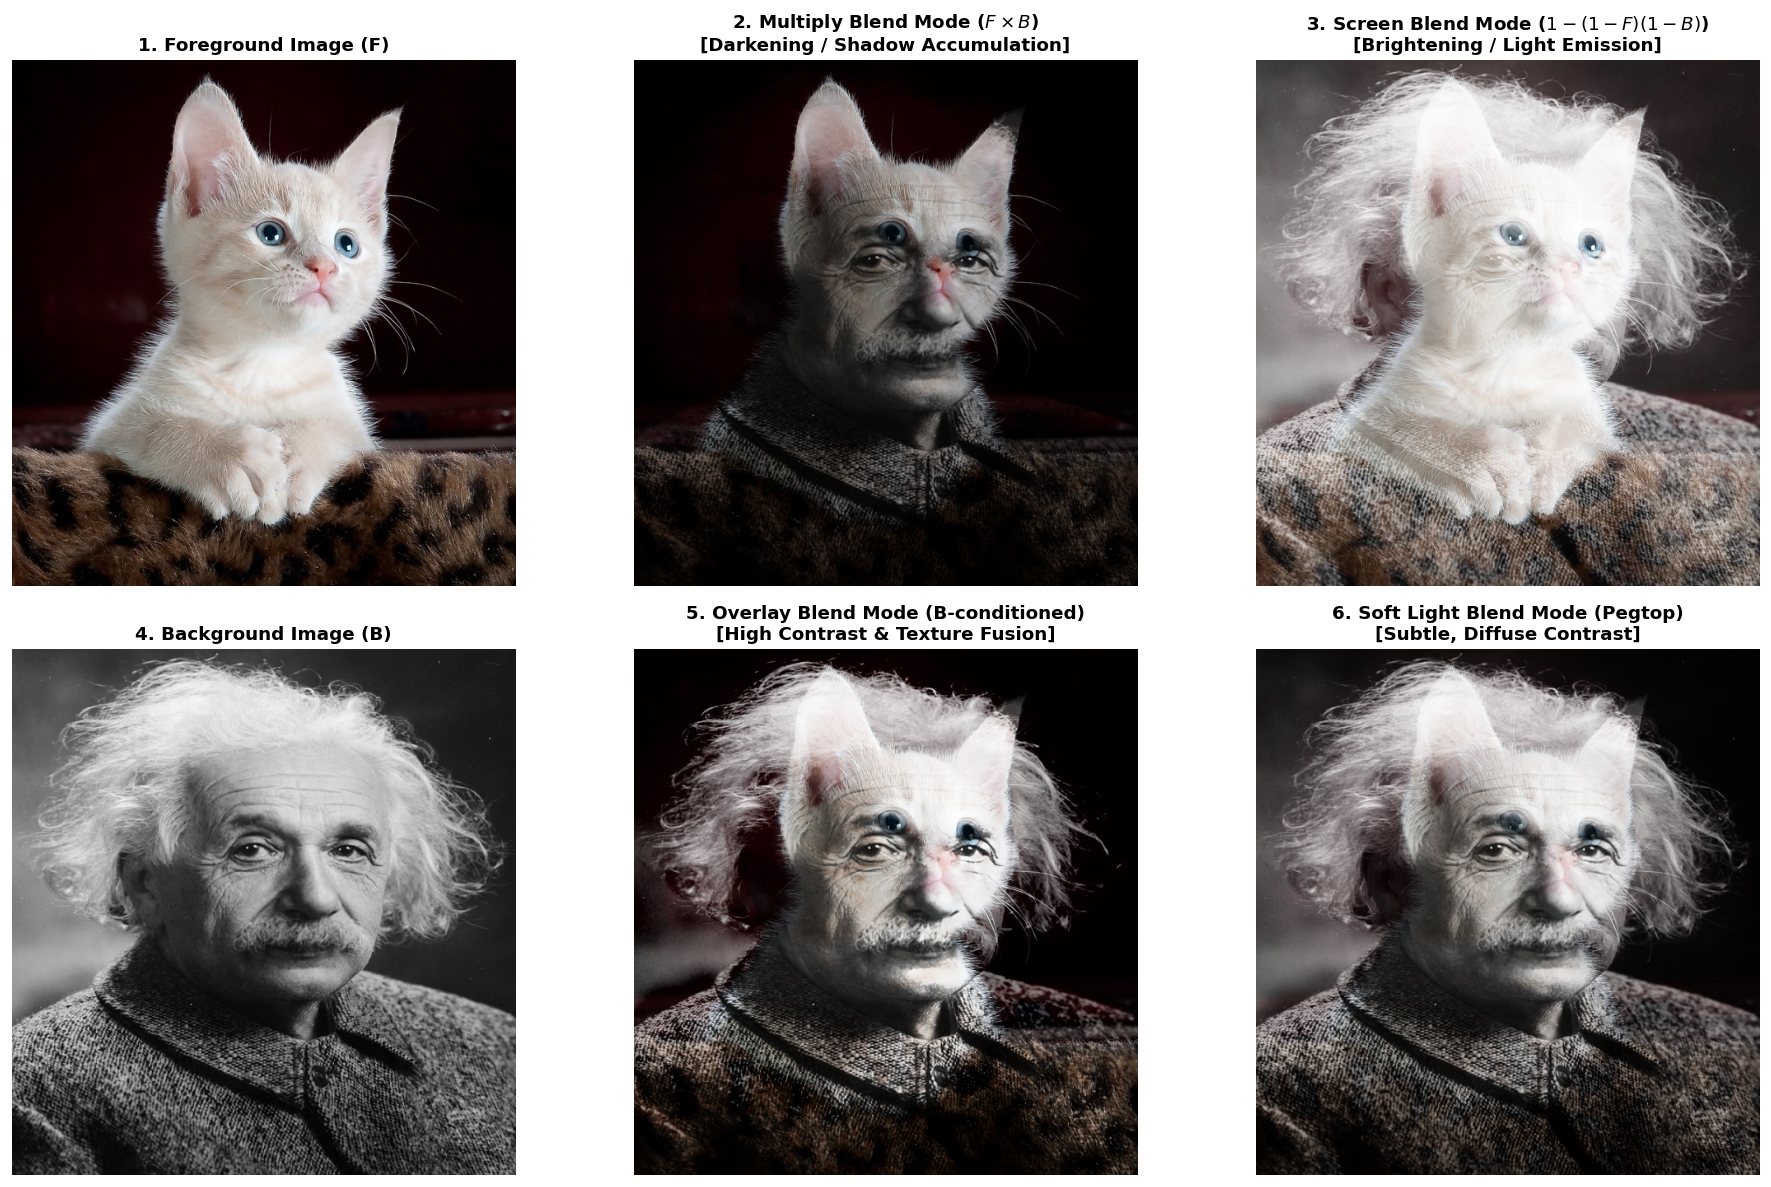

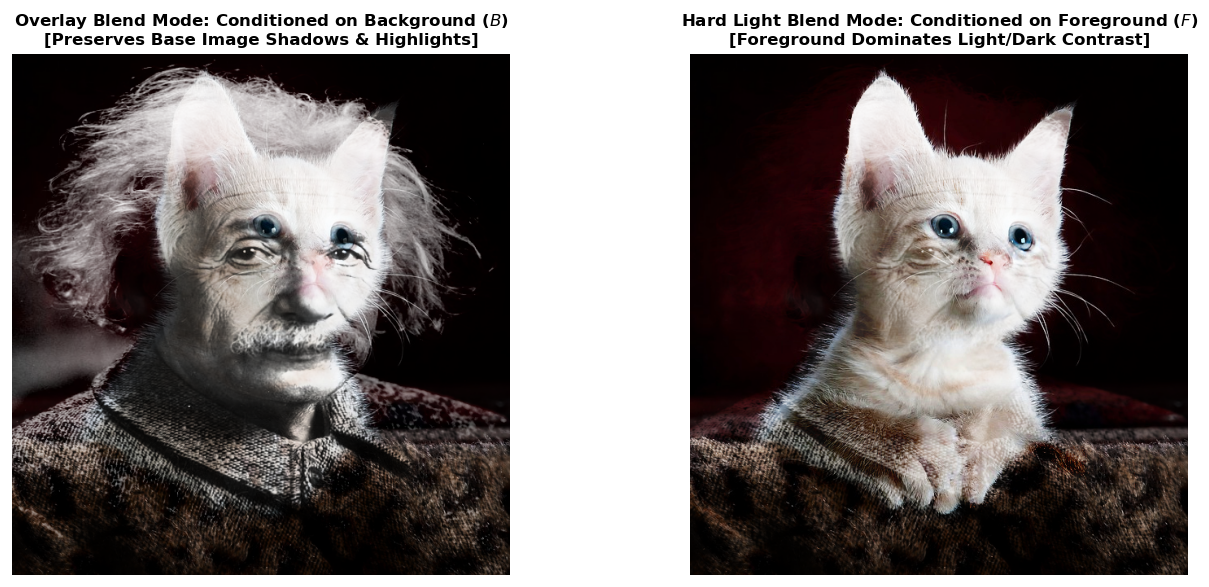

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Base Inputs & Darken/Lighten Modes
axes[0, 0].imshow(img_fg)
axes[0, 0].set_title("1. Foreground Image (F)", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_multiply)
axes[0, 1].set_title("2. Multiply Blend Mode ($F \\times B$)\n[Darkening / Shadow Accumulation]", fontsize=11, fontweight="bold")
axes[0, 1].axis("off")

axes[0, 2].imshow(img_screen)
axes[0, 2].set_title("3. Screen Blend Mode ($1 - (1-F)(1-B)$)\n[Brightening / Light Emission]", fontsize=11, fontweight="bold")
axes[0, 2].axis("off")

# Row 2: Background & Contrast Modes
axes[1, 0].imshow(img_bg)
axes[1, 0].set_title("4. Background Image (B)", fontsize=11, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_overlay)
axes[1, 1].set_title("5. Overlay Blend Mode (B-conditioned)\n[High Contrast & Texture Fusion]", fontsize=11, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(img_soft_light)
axes[1, 2].set_title("6. Soft Light Blend Mode (Pegtop)\n[Subtle, Diffuse Contrast]", fontsize=11, fontweight="bold")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Additional Side-by-Side: Overlay vs Hard Light
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_overlay)
axes[0].set_title("Overlay Blend Mode: Conditioned on Background ($B$)\n[Preserves Base Image Shadows & Highlights]", fontsize=10, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_hard_light)
axes[1].set_title("Hard Light Blend Mode: Conditioned on Foreground ($F$)\n[Foreground Dominates Light/Dark Contrast]", fontsize=10, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## (vi) Quantitative Statistical Comparison & Luminance Distribution Analysis

In [7]:
def compute_blend_statistics(img_dict: dict):
    """
    Compute mean luminance, standard deviation (contrast), and Shannon entropy across blend modes.
    """
    print("=" * 80)
    print(f"{'Blend Mode':<22} | {'Mean (μ)':<10} | {'Std Dev (σ)':<12} | {'Dynamic Range':<15} | {'Entropy (H)':<12}")
    print("=" * 80)
    
    for name, img in img_dict.items():
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mean_val = float(gray.mean())
        std_val = float(gray.std())
        dr_str = f"[{gray.min()}, {gray.max()}]"
        
        # Shannon Entropy
        hist = np.bincount(gray.ravel(), minlength=256)
        pdf = hist / gray.size
        pdf_nz = pdf[pdf > 0]
        entropy = float(-np.sum(pdf_nz * np.log2(pdf_nz)))
        
        print(f"{name:<22} | {mean_val:<10.2f} | {std_val:<12.2f} | {dr_str:<15} | {entropy:<12.4f}")
    print("=" * 80)


blend_modes_dict = {
    "Foreground (F)": img_fg,
    "Background (B)": img_bg,
    "Linear Alpha (0.5)": linear_blends[2],
    "Multiply": img_multiply,
    "Screen": img_screen,
    "Overlay": img_overlay,
    "Hard Light": img_hard_light,
    "Soft Light": img_soft_light,
}

compute_blend_statistics(blend_modes_dict)


Blend Mode             | Mean (μ)   | Std Dev (σ)  | Dynamic Range   | Entropy (H) 
Foreground (F)         | 69.90      | 80.92        | [0, 255]        | 6.7025      
Background (B)         | 100.27     | 65.99        | [0, 247]        | 7.7595      
Linear Alpha (0.5)     | 85.09      | 53.40        | [1, 240]        | 7.4792      
Multiply               | 28.44      | 46.08        | [0, 225]        | 5.6822      
Screen                 | 141.69     | 70.71        | [2, 255]        | 7.8338      
Overlay                | 69.12      | 77.39        | [0, 255]        | 7.0046      
Hard Light             | 61.60      | 81.48        | [0, 255]        | 6.5427      
Soft Light             | 79.52      | 70.75        | [0, 252]        | 7.5636      


## (vii) Analytical Discussion: Applications in Computer Graphics & Photo Editing

### 1. Mathematical Breakdown of Blend Mode Categories

| Category | Modes | Formula | Neutral Color | Primary Visual Effect | Typical Industrial Application |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Linear Interpolation** | Linear Alpha | $(1-\alpha)B + \alpha F$ | N/A | Linear cross-fade between layers | Video transitions, transparency sliders, UI fading |
| **Darkening (Subtractive)** | Multiply | $F \times B$ | White ($1.0$) | Darkens image; preserves dark tones | Shadow generation, ink simulation, scanned sketch line extraction |
| **Lightening (Additive)** | Screen | $1 - (1-F)(1-B)$ | Black ($0.0$) | Brightens image; preserves light tones | Light leaks, flare effects, glowing particles, fire compositing |
| **Contrast Enhancement** | Overlay | Piecewise on $B$ | $50\%$ Gray | Boosts midtone contrast; preserves highlights/shadows | Texture mapping, watermark blending, stylized color grading |
| **Direct Lighting** | Hard Light | Piecewise on $F$ | $50\%$ Gray | Harsh spotlight illumination; high key rendering | Harsh cast shadows, specular lighting reflections |
| **Diffuse Lighting** | Soft Light | $(1-2F)B^2 + 2FB$ | $50\%$ Gray | Gentle, diffused contrast boost | Portrait skin smoothing, dodging & burning, atmospheric haze |

---

### 2. Simple Alpha Blending vs. Porter-Duff Alpha Compositing
- **Simple Alpha Blending ($C = (1-\alpha)B + \alpha F$):**
  Assumes that the background layer is $100\%$ opaque ($\alpha_B = 1.0$). While computationally trivial and supported directly in hardware via `cv2.addWeighted`, it fails when compositing multiple overlapping transparent layers onto an alpha background.
- **Porter-Duff "Over" Compositing ($C = \frac{\alpha_F F + \alpha_B(1-\alpha_F)B}{\alpha_C}$):**
  Correctly tracks the cumulative optical transmission $\alpha_C = \alpha_F + \alpha_B(1-\alpha_F)$. This ensures that if both foreground and background are semi-transparent (e.g. $\alpha_F = 0.5, \alpha_B = 0.5 \implies \alpha_C = 0.75$), the output correctly accumulates opacity, which is foundational in modern rendering engines (OpenGL, Vulkan, CSS Compositing, Photoshop layer stacks).

---

### 3. Applications in Computer Graphics & Photo Retouching
1. **Texture Mapping & Material Synthesis:**
   By applying **Overlay** or **Multiply** blending, procedural texture maps (wood grain, metal roughness, canvas cloth) are seamlessly transferred onto base 3D models without washing out diffuse lighting.
2. **Visual Effects & Atmospheric Simulation:**
   **Screen** mode allows explosive fire, smoke, and lens flares rendered on black backgrounds to be composited directly onto scene plates without requiring explicit segmentation masks (since black $0.0$ has zero additive effect).
3. **Non-Destructive Portrait Retouching:**
   **Soft Light** layers filled with $50\%$ neutral gray allow digital painters to perform non-destructive **Dodge & Burn** adjustments (painting with white highlights areas and painting with black shadows areas).
